# 07 Training a CNN on Image Datasets (CIFAR-10)

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load **CIFAR-10**, preprocess it, and inspect shape and labels
- Build a small **CNN**, train it for a few epochs, and plot **loss/accuracy**
- Evaluate on the test set and see sample predictions

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 07 "Early Stopping and Regularization" — the overfitting cure you learned there is what keeps this CIFAR-10 run honest.

---

## 🌍 Real life

**📌 Real case — the benchmark that was withdrawn.** CIFAR-10 is a hand-labelled subset of the **80 Million Tiny Images** collection (Torralba, Fergus & Freeman, 2008). In **June 2020** MIT took that parent dataset offline permanently and asked the community to stop using it, after Prabhu and Birhane documented racist and misogynistic labels among its automatically-harvested WordNet noun categories. The creators' own explanation was that the corpus was too large and its 32×32 images too small for anyone to inspect what was in it. CIFAR-10's ten classes are clean — but the benchmark you are about to train on descends from a dataset its own authors withdrew, and that is a fact about **every** dataset you will ever be handed: someone assembled it, at scale, without looking at all of it.

**⚡ Why this matters — what goes wrong without it.** CIFAR-10 is where MNIST stops flattering you. The same two-conv-block recipe that reached **0.9867** on MNIST in notebook `01` reaches **0.6230** here. Nothing changed but the images: real photographs, in colour, with the object at any scale, angle and lighting. If you only ever report MNIST numbers, you will promise a client 98% and deliver 62%.

**Where is this used?** Training CNNs on image datasets is used in **product recognition**, **quality inspection**, and **medical image classification**.

**In this notebook we use** a **CNN** to **classify CIFAR-10** (32×32 color images, 10 classes). We use **CIFAR-10** (instead of ImageNet for this demo) **because** it is small and fast to train so you see the full pipeline in ~10 min.

**📌 Covers slide(s):** **11** — Image Segmentation / image pipelines (see README). *Do this notebook after core transfer-learning notebooks (05, 06).*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **CIFAR-10:** 50k train + 10k test, 32×32 RGB, 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).
- **Pipeline:** Load data → normalize → build CNN (Conv2D, MaxPool, Dense) → compile → train → evaluate.
- **We use a CNN** (instead of MLP on flattened pixels) because images have **spatial structure**; conv layers preserve it.
- **We use a small subset or few epochs** here so the notebook runs in ~10 min; in real projects you'd train longer.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. CIFAR-10 (built-in). We use a subset or 3 epochs so it runs quickly.

**Dataset:** Real — CIFAR-10 (natural images, 10 classes).

**Outputs:** Training/validation loss and accuracy curves (with axis labels), test accuracy, and a few sample predictions (true → predicted).

## Step 1: Imports and load CIFAR-10

In [1]:
# WHAT: import libraries and load CIFAR-10 (60,000 32x32 color photos in 10 classes).
# WHY: CIFAR-10 is the classic step up from MNIST - real objects, color channels, much more variation.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    # Scale pixels to 0-1 and flatten the label arrays to simple vectors.
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    y_train, y_test = y_train.flatten(), y_test.flatten()
    print("Train:", x_train.shape, "Test:", x_test.shape)
    print("Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)")
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)
Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)


## Step 2: Build CNN (we use Conv2D + MaxPool for spatial structure instead of flattening first)

In [2]:
# WHAT: define and compile a small CNN for 32x32 RGB inputs.
# WHY: the same two-conv-block pattern as MNIST - only the input shape (32, 32, 3) changed for color photos.
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (3 epochs so it runs in ~5–10 min)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_split=0.1, epochs=3, batch_size=128, verbose=1)

Epoch 1/3


  1/352 ━━━━━━━━━━━━━━━━━━━━ 1:43 295ms/step - accuracy: 0.0781 - loss: 2.3145

  6/352 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1419 - loss: 2.2931   

 11/352 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1591 - loss: 2.2705

 16/352 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1675 - loss: 2.2395

...

335/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5976 - loss: 1.1495

340/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5981 - loss: 1.1481

345/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5986 - loss: 1.1474

350/352 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5991 - loss: 1.1464

352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5991 - loss: 1.1466 - val_accuracy: 0.6228 - val_loss: 1.0905


## Step 4: Plot loss and accuracy

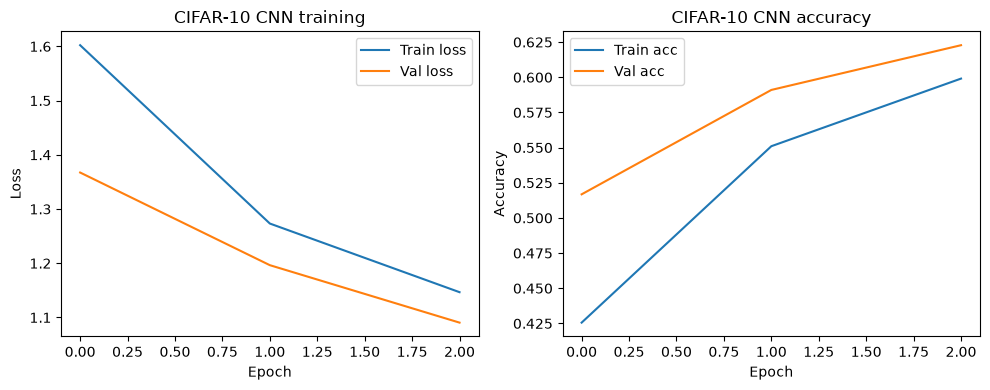

In [4]:
# WHAT: plot CIFAR-10 training/validation loss and accuracy.
# WHY: the train-vs-validation gap shows how much the model memorizes rather than generalizes.
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("CIFAR-10 CNN training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("CIFAR-10 CNN accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()

## Step 5: Evaluate and sample predictions

In [5]:
# WHAT: evaluate on the test set and show a few true-vs-predicted pairs.
# WHY: held-out accuracy is the honest score; inspecting predictions shows which classes get confused.
if HAS_TF:
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % test_acc)
    preds = np.argmax(model.predict(x_test[:5]), axis=1)
    print("Sample (true → predicted):", list(zip(y_test[:5].tolist(), preds.tolist())))

Test accuracy: 0.6230
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Sample (true → predicted): [(3, 3), (8, 8), (8, 8), (0, 8), (6, 6)]


## 💬 Discuss

1. Same architecture, same optimizer, same epoch budget: **0.9867** on MNIST and **0.6230** on CIFAR-10. Write the one sentence you would put in a report to explain that gap to a non-technical manager — without making the model sound broken and without making it sound fine.
2. The model called an airplane a ship. In a system that flags aircraft near an airport perimeter, which direction of that mistake is worse — airplane→ship or ship→airplane? Now say what you would change in the training so the model shares your preference.
3. You have one more hour of compute. More epochs, data augmentation, or a bigger model? Defend your choice using what the loss and accuracy curves in Step 4 actually show — not what you expect them to show.


## 🌍 Real-World Worked Example — CIFAR-10 Image Classifier

**Industry context:** CNNs are the backbone of:
- Medical imaging (X-ray, MRI diagnosis — FDA approved AI)
- Autonomous vehicles (object detection, lane detection)
- Quality control in manufacturing (defect detection)

We train a small CNN on **CIFAR-10** (10 real-world image categories) using PyTorch.

Epoch 1/10 — loss: 1.900


Epoch 2/10 — loss: 1.555


Epoch 3/10 — loss: 1.371


Epoch 4/10 — loss: 1.257


Epoch 5/10 — loss: 1.143


Epoch 6/10 — loss: 1.019


Epoch 7/10 — loss: 0.907


Epoch 8/10 — loss: 0.814


Epoch 9/10 — loss: 0.704


Epoch 10/10 — loss: 0.590

Test accuracy: 58.3%  (industry models reach 99%+ with bigger architectures)


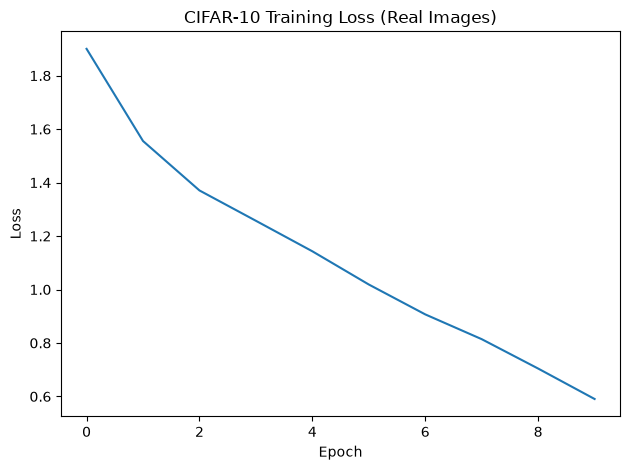

In [6]:
# WHAT: train a small CNN on real CIFAR-10 photos end to end and report test accuracy.
# WHY: real color photos are much harder than MNIST digits - this is the full pipeline on realistic data.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# ── Load CIFAR-10 (downloads ~170MB once, cached after) ────────────────────
# Normalize each RGB channel to roughly [-1, 1] so training is stable.
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True, transform=transform)

# Use a small subset for fast demo
from torch.utils.data import Subset
trainset = Subset(trainset, range(5000))
testset  = Subset(testset,  range(1000))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# ── CNN Model ─────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Two Conv+Pool blocks extract features; Dropout fights overfitting before the final 10-way classifier.
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model   = SmallCNN()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

# Standard loop: predict, measure loss, backpropagate, update - once per batch, for 10 epochs.
for epoch in range(10):
    model.train(); epoch_loss=0
    for X,y in trainloader:
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(trainloader))
    print(f"Epoch {epoch+1}/10 — loss: {losses[-1]:.3f}")

# Evaluation with gradients off: count correct predictions on the held-out test set.
model.eval()
correct=0; total=0
with torch.no_grad():
    for X,y in testloader:
        correct += (model(X).argmax(1)==y).sum().item(); total += len(y)
print(f"\nTest accuracy: {correct/total*100:.1f}%  (industry models reach 99%+ with bigger architectures)")

plt.plot(losses); plt.title("CIFAR-10 Training Loss (Real Images)"); plt.xlabel("Epoch")
plt.ylabel("Loss"); plt.tight_layout(); plt.show()

## ⚠️ Where this breaks

- **0.6230 is not "a CNN's accuracy on CIFAR-10". It is three epochs' accuracy.** Look at the curves in Step 4: they have not flattened. Reporting a number from a run you stopped early — because the notebook had to finish in ten minutes — is the single most common dishonesty in student project reports. Say the epoch count next to the number, always.
- **Accuracy hides which classes collide.** Our sample predictions include `(0 → 8)`: an airplane called a ship. Both are usually a small object on a large expanse of blue. A confusion matrix would have shown that immediately; a single accuracy number never will. Report the matrix.
- **32×32 pixels is a hard ceiling.** Some CIFAR-10 images are genuinely ambiguous to *humans* at that resolution. No architecture recovers information the image does not contain, and no amount of training will push you past that floor.
- **The assumption that must hold:** exactly one of your ten classes is present in every image. A real shelf photo contains twelve products; a real chest X-ray can carry three findings at once. Softmax cannot express that — you need multi-label training with sigmoid outputs, and a completely different metric.
- **Cheaper alternative:** for ten fixed object classes, a frozen ImageNet backbone plus a head (`05`, `06`) will beat this from-scratch CNN at a fraction of the training cost — our own worked examples reached roughly 90% on a 2-class task from **400** images.


## 🧩 Mini-exercise

**Try it (choose one):** Add simple data augmentation (e.g. random flip or small rotation) before training and run for 2 epochs. Does test accuracy change? Or increase epochs to 5 and see if the model starts to overfit.

---

## ✅ Summary

**What you did:** Loaded CIFAR-10, built a CNN, trained for 3 epochs, plotted loss/accuracy, and evaluated with sample predictions.

**In real life you'd also:** Use data augmentation, more epochs, learning rate scheduling, and early stopping.

**The main idea:** Training a CNN on an image dataset follows: load → preprocess → build CNN → train → evaluate; we use conv layers to exploit spatial structure.

**Next:** `04_transfer_learning_object_detection` extends transfer learning to object detection; `01_cnn_architecture` introduces CNN layers.

## 📚 References

1. Krizhevsky, A., Sutskever, I. & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. NeurIPS. https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html
2. He, K., Zhang, X., Ren, S. & Sun, J. (2016). *Deep Residual Learning for Image Recognition* (ResNet). CVPR. https://arxiv.org/abs/1512.03385
3. Cubuk, E. D., Zoph, B., Shlens, J. & Le, Q. V. (2020). *RandAugment: Practical Automated Data Augmentation with a Reduced Search Space*. NeurIPS. https://arxiv.org/abs/1909.13719

**Recent work (2024–2026)**

4. Siméoni, O. et al. (2025). *DINOv3*. arXiv. https://arxiv.org/abs/2508.10104 — the 2026 alternative to "collect labels, then train a CNN": pretrain on unlabelled images, then attach a light head.
5. Wang, C. et al. (2024). *Real-IAD: A Real-World Multi-View Dataset for Benchmarking Versatile Industrial Anomaly Detection*. CVPR 2024. https://arxiv.org/abs/2403.12580 — a CVPR 2024 dataset built because the mainstream inspection benchmarks are saturated above 99% AUROC — a reminder that a high accuracy number often measures the dataset's difficulty, not your architecture.
